<a href="https://colab.research.google.com/github/bloom2791410/Cervical-Cancer-Prediction/blob/main/src/main_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project

Giải nén xong!
['risk_factors_cervical_cancer.csv']
Shape: (858, 36)
   Age Number of sexual partners First sexual intercourse Num of pregnancies  \
0   18                       4.0                     15.0                1.0   
1   15                       1.0                     14.0                1.0   
2   34                       1.0                        ?                1.0   
3   52                       5.0                     16.0                4.0   
4   46                       3.0                     21.0                4.0   

  Smokes Smokes (years) Smokes (packs/year) Hormonal Contraceptives  \
0    0.0            0.0                 0.0                     0.0   
1    0.0            0.0                 0.0                     0.0   
2    0.0            0.0                 0.0                     0.0   
3    1.0           37.0                37.0                     1.0   
4    0.0            0.0                 0.0                     1.0   

  Hormonal Contraceptiv

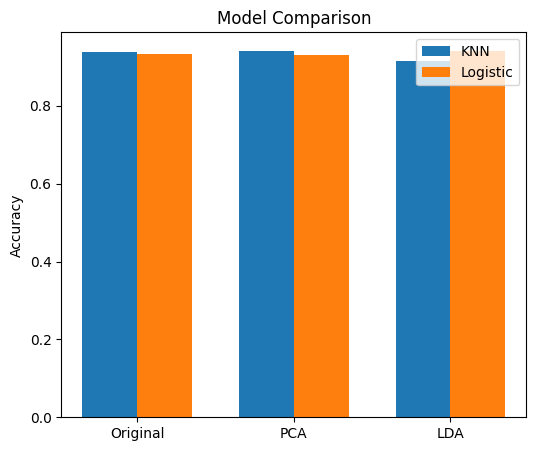

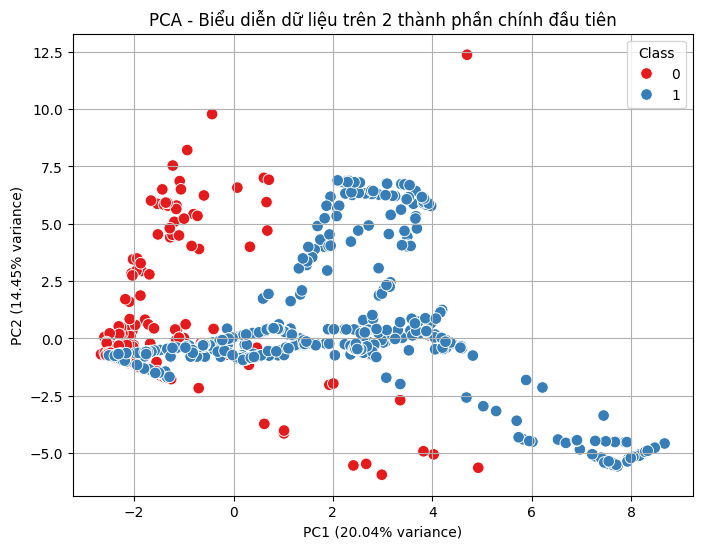

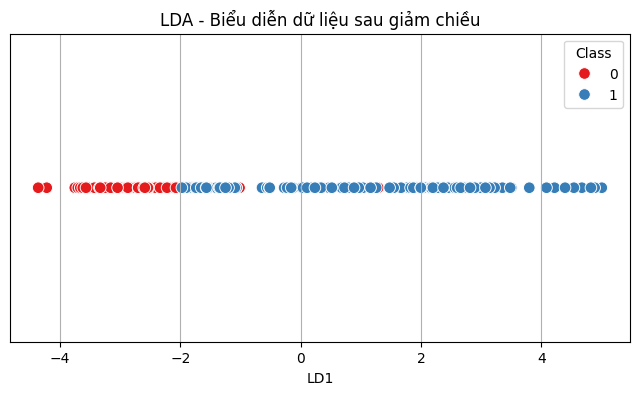

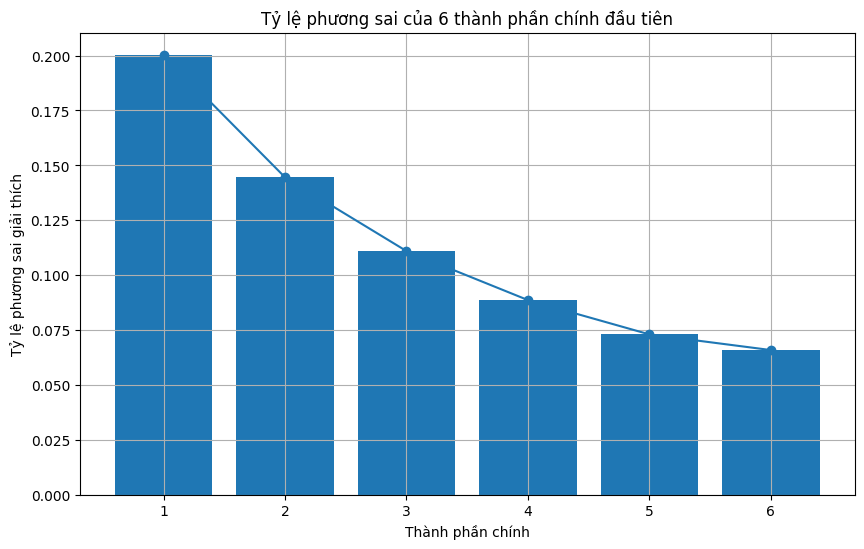

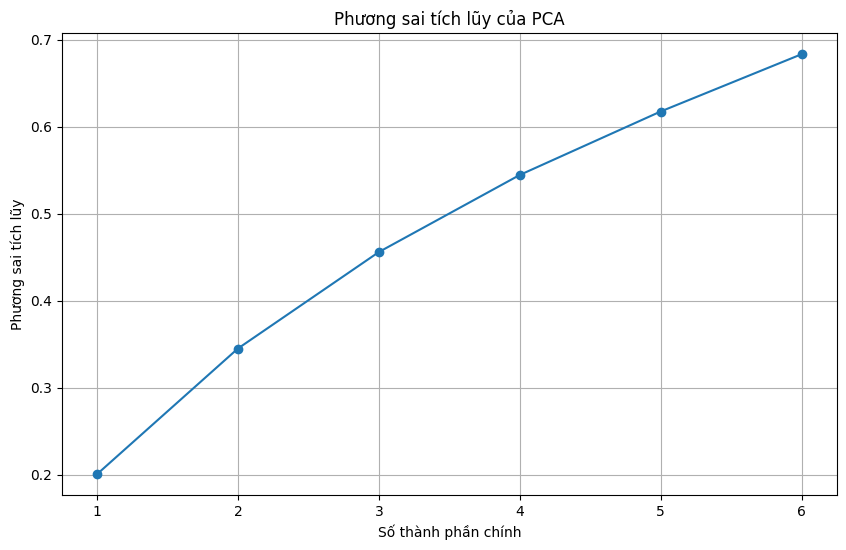

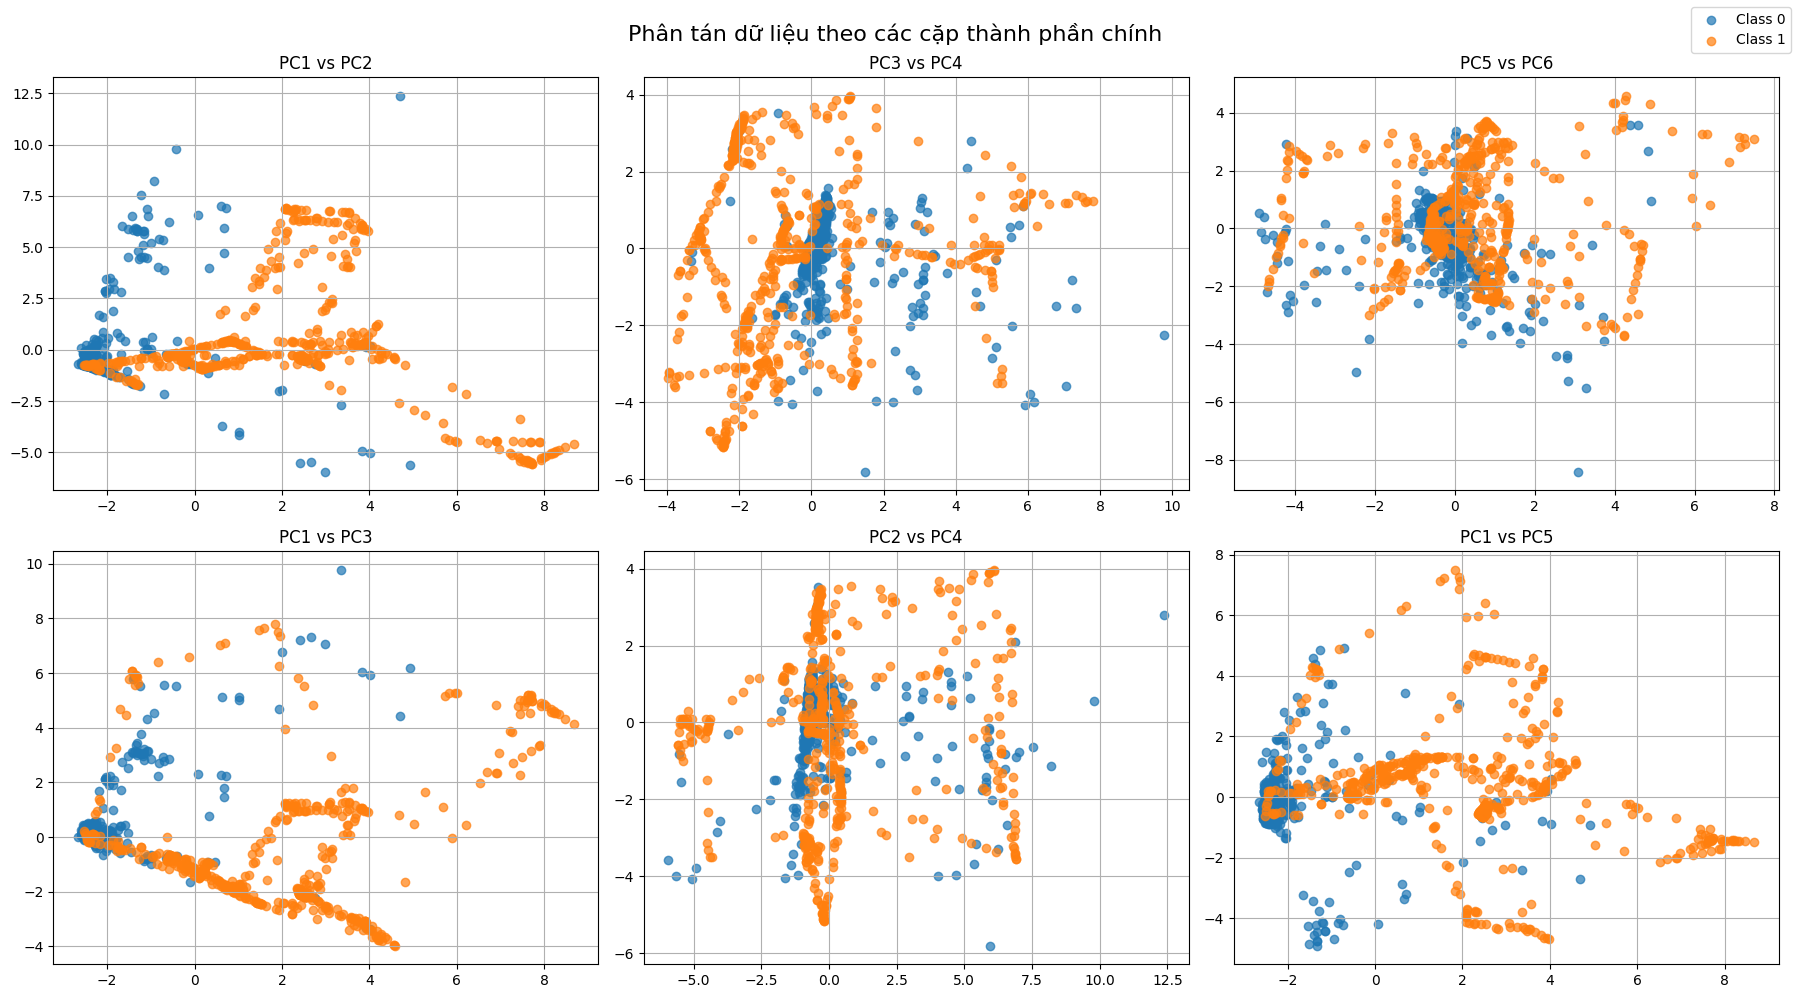

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE

import zipfile
import os


# 1. LOAD DATA
zip_path = "cervical+cancer+risk+factors.zip"
extract_path = "./data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Giải nén xong!")

print(os.listdir("./data"))

df = pd.read_csv("./data/risk_factors_cervical_cancer.csv")

print("Shape:", df.shape)
print(df.head())

# 2. TIỀN XỬ LÝ

# Replace '?' → NaN
df.replace('?', np.nan, inplace=True)

# Convert numeric
df = df.apply(pd.to_numeric)

# Drop cột missing quá nhiều
df.drop([
    'STDs: Time since first diagnosis',
    'STDs: Time since last diagnosis'
], axis=1, inplace=True)

# Fill missing bằng median
df.fillna(df.median(), inplace=True)


# 3. CHỌN TARGET
y = df['Biopsy']
X = df.drop(['Biopsy'], axis=1)

# 4. TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# 5. SCALE
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. XỬ LÝ IMBALANCE
smote = SMOTE(random_state=42)
X_train_scaled, y_train = smote.fit_resample(X_train_scaled, y_train)

print("Sau SMOTE:", np.bincount(y_train))

# 7. PCA
pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Số chiều sau PCA:", X_train_pca.shape[1])

# 8. LDA
lda = LinearDiscriminantAnalysis(n_components=1)
X_train_lda = lda.fit_transform(X_train_scaled, y_train)
X_test_lda = lda.transform(X_test_scaled)

# 9. MODEL

# ---- KNN (TUNE K)
param_knn = {'n_neighbors': np.arange(3, 21, 2)}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_knn, cv=5)
grid_knn.fit(X_train_scaled, y_train)

best_knn = grid_knn.best_estimator_
print("Best KNN:", grid_knn.best_params_)

# ---- Logistic (TUNE)
param_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear']
}
grid_lr = GridSearchCV(LogisticRegression(max_iter=2000), param_lr, cv=5)
grid_lr.fit(X_train_scaled, y_train)

best_lr = grid_lr.best_estimator_
print("Best Logistic:", grid_lr.best_params_)

# 10. TRAIN & PREDICT

# --- KNN
y_knn = best_knn.fit(X_train_scaled, y_train).predict(X_test_scaled)
y_knn_pca = best_knn.fit(X_train_pca, y_train).predict(X_test_pca)
y_knn_lda = best_knn.fit(X_train_lda, y_train).predict(X_test_lda)

# --- Logistic
y_lr = best_lr.fit(X_train_scaled, y_train).predict(X_test_scaled)
y_lr_pca = best_lr.fit(X_train_pca, y_train).predict(X_test_pca)
y_lr_lda = best_lr.fit(X_train_lda, y_train).predict(X_test_lda)

# 11. EVALUATION
def evaluate(y_true, y_pred, name):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Report:\n", classification_report(y_true, y_pred))

# KNN
evaluate(y_test, y_knn, "KNN - Original")
evaluate(y_test, y_knn_pca, "KNN - PCA")
evaluate(y_test, y_knn_lda, "KNN - LDA")

# Logistic
evaluate(y_test, y_lr, "Logistic - Original")
evaluate(y_test, y_lr_pca, "Logistic - PCA")
evaluate(y_test, y_lr_lda, "Logistic - LDA")

# 12. SO SÁNH
results = {
    "KNN": [
        accuracy_score(y_test, y_knn),
        accuracy_score(y_test, y_knn_pca),
        accuracy_score(y_test, y_knn_lda)
    ],
    "Logistic": [
        accuracy_score(y_test, y_lr),
        accuracy_score(y_test, y_lr_pca),
        accuracy_score(y_test, y_lr_lda)
    ]
}

labels = ["Original", "PCA", "LDA"]
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6,5))
plt.bar(x - width/2, results["KNN"], width, label="KNN")
plt.bar(x + width/2, results["Logistic"], width, label="Logistic")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.legend()
plt.show()




# 13. TRỰC QUAN HÓA PCA & LDA
# PCA 2D Visualization
# PCA 2 chiều để trực quan hóa
pca_vis = PCA(n_components=2)

X_pca_vis = pca_vis.fit_transform(X_train_scaled)
# DataFrame
pca_df = pd.DataFrame({
    'PC1': X_pca_vis[:, 0],
    'PC2': X_pca_vis[:, 1],
    'Class': y_train
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Class',
    palette='Set1',
    s=70
)

plt.title("PCA - Biểu diễn dữ liệu trên 2 thành phần chính đầu tiên")

plt.xlabel(
    f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.2f}% variance)"
)

plt.ylabel(
    f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.2f}% variance)"
)

plt.grid(True)

plt.show()


# LDA Visualization

# Với bài toán nhị phân → chỉ có 1 LD
lda_vis = LinearDiscriminantAnalysis(n_components=1)

X_lda_vis = lda_vis.fit_transform(X_train_scaled, y_train)

lda_df = pd.DataFrame({
    'LD1': X_lda_vis[:, 0],
    'Class': y_train
})

plt.figure(figsize=(8,4))

sns.scatterplot(
    data=lda_df,
    x='LD1',
    y=np.zeros(len(lda_df)),
    hue='Class',
    palette='Set1',
    s=70
)

plt.title("LDA - Biểu diễn dữ liệu sau giảm chiều")

plt.xlabel("LD1")

plt.yticks([])

plt.grid(True)

plt.show()

# Explained Variance - 6 thành phần chính đầu tiên

pca_full = PCA()

pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_

plt.figure(figsize=(10,6))

plt.bar(
    range(1, 7),
    explained[:6]
)

plt.plot(
    range(1, 7),
    explained[:6],
    marker='o'
)

plt.xlabel("Thành phần chính")
plt.ylabel("Tỷ lệ phương sai giải thích")

plt.title(
    "Tỷ lệ phương sai của 6 thành phần chính đầu tiên"
)

plt.xticks(range(1, 7))

plt.grid(True)

plt.show()


# Cumulative Variance

cum_var = np.cumsum(explained)

plt.figure(figsize=(10,6))

plt.plot(
    range(1, 7),
    cum_var[:6],
    marker='o'
)

plt.xlabel("Số thành phần chính")

plt.ylabel("Phương sai tích lũy")

plt.title("Phương sai tích lũy của PCA")

plt.xticks(range(1, 7))

plt.grid(True)

plt.show()

# =========================
# PHÂN TÁN DỮ LIỆU THEO CÁC CẶP TPC
# =========================

# PCA 6 thành phần chính
pca_vis = PCA(n_components=6)

X_pca_vis = pca_vis.fit_transform(X_train_scaled)

# Các cặp cần vẽ:
# (PC1, PC2)
# (PC3, PC4)
# (PC5, PC6)
# (PC1, PC3)
# (PC2, PC4)
# (PC1, PC5)

pairs = [
    (0, 1),
    (2, 3),
    (4, 5),
    (0, 2),
    (1, 3),
    (0, 4)
]

titles = [
    "PC1 vs PC2",
    "PC3 vs PC4",
    "PC5 vs PC6",
    "PC1 vs PC3",
    "PC2 vs PC4",
    "PC1 vs PC5"
]

# VẼ
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for idx, ((i, j), title) in enumerate(zip(pairs, titles)):

    ax = axes[idx]

    for label in np.unique(y_train):

        ax.scatter(
            X_pca_vis[y_train == label, i],
            X_pca_vis[y_train == label, j],
            label=f'Class {label}',
            alpha=0.7
        )



    ax.set_title(title)

    ax.grid(True)

# legend chung
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc='upper right'
)

plt.suptitle(
    "Phân tán dữ liệu theo các cặp thành phần chính",
    fontsize=16
)

plt.tight_layout()

plt.show()

# PHÂN BỐ DỮ LIỆU BIOPSY

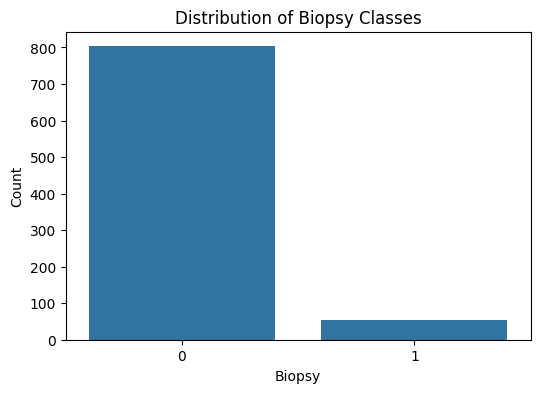

In [ ]:

#  PHÂN BỐ DỮ LIỆU BIOPSY (Trước xử lý)
import os

os.makedirs("images", exist_ok=True)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(x=y)

plt.title("Distribution of Biopsy Classes")
plt.xlabel("Biopsy")
plt.ylabel("Count")

plt.savefig("images/biopsy_distribution.png", dpi=300)
plt.show()

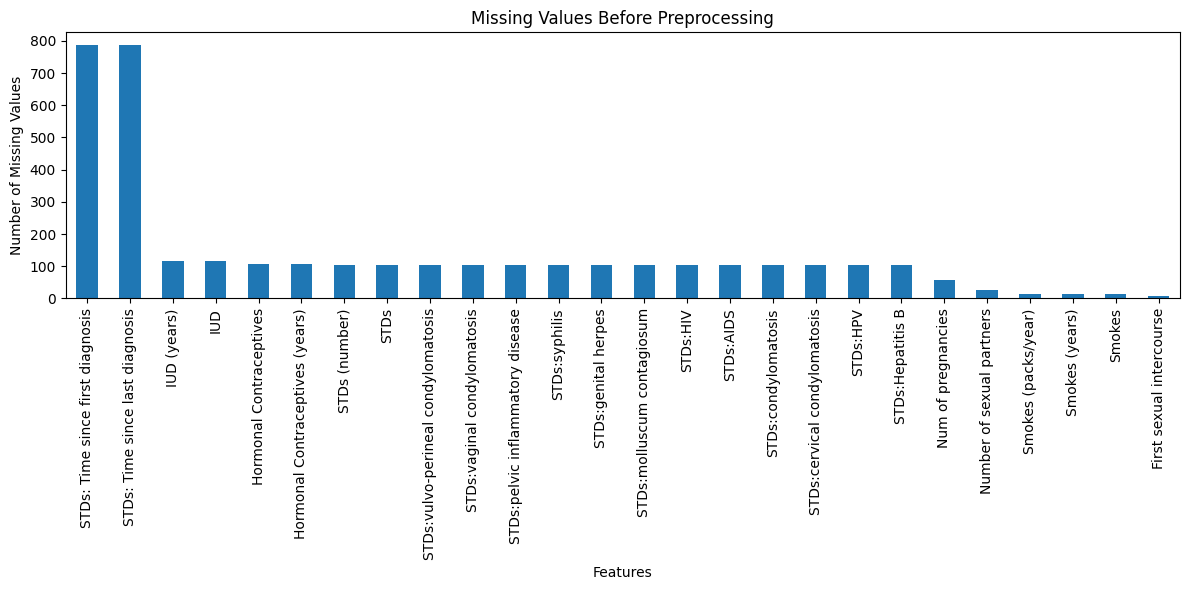

In [ ]:

# MISSING VALUES (TRƯỚC XỬ LÝ)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

# đọc lại dữ liệu gốc
df_raw = pd.read_csv("risk_factors_cervical_cancer.csv")

# thay ? thành NaN
df_raw.replace('?', np.nan, inplace=True)

# đếm missing
missing = df_raw.isnull().sum()

# chỉ lấy cột có missing
missing = missing[missing > 0]

# sắp xếp giảm dần
missing = missing.sort_values(ascending=False)

# vẽ biểu đồ
plt.figure(figsize=(12,6))

missing.plot(kind='bar')

plt.title("Missing Values Before Preprocessing")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")

plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig(
    "images/missing_values.png",
    dpi=300
)

plt.show()

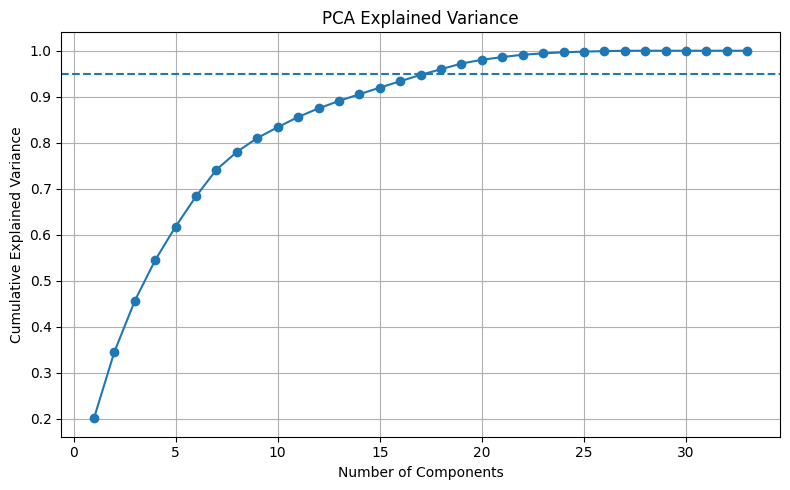

In [ ]:

# PCA EXPLAINED VARIANCE

import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# tạo folder images
os.makedirs("images", exist_ok=True)

# PCA FULL COMPONENTS

pca_full = PCA()

pca_full.fit(X_train_scaled)

# TÍNH PHƯƠNG SAI TÍCH LŨY

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

# VẼ BIỂU ĐỒ

plt.figure(figsize=(8,5))

plt.plot(
    range(
        1,
        len(cumulative_variance)+1
    ),
    cumulative_variance,
    marker='o'
)

# đường mức 95%
plt.axhline(
    y=0.95,
    linestyle='--'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)


plt.tight_layout()

plt.savefig(
    "images/pca_variance.png",
    dpi=300
)

plt.show()

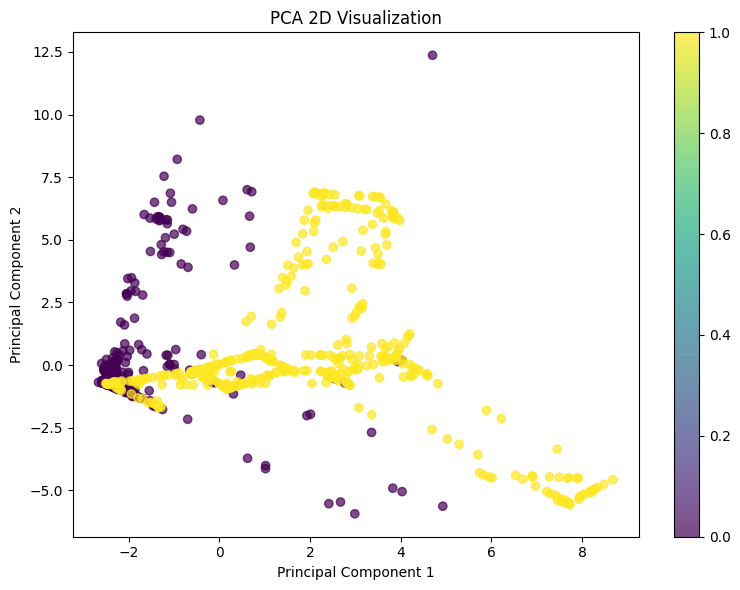

In [ ]:

# PCA 2D VISUALIZATION

import os
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# tạo folder images
os.makedirs("images", exist_ok=True)

# GIẢM CHIỀU VỀ 2D
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(
    X_train_scaled
)

# VẼ SCATTER PLOT

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca_2d[:,0],
    X_pca_2d[:,1],
    c=y_train,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("PCA 2D Visualization")

plt.colorbar(scatter)


plt.tight_layout()

plt.savefig(
    "images/pca_2d.png",
    dpi=300
)

plt.show()

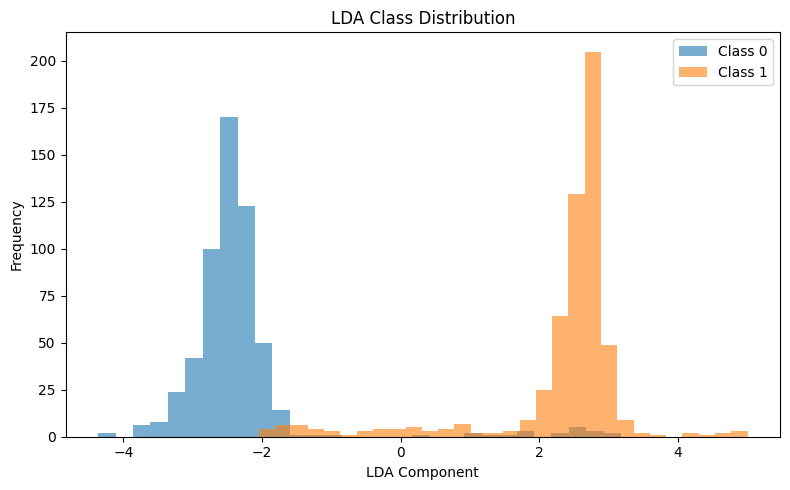

In [ ]:

# ẢNH 6 - LDA VISUALIZATION

import os
import matplotlib.pyplot as plt

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# tạo folder images
os.makedirs("images", exist_ok=True)

# GIẢM CHIỀU BẰNG LDA
lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(
    X_train_scaled,
    y_train
)

# VẼ PHÂN PHỐI 2 LỚP

plt.figure(figsize=(8,5))

plt.hist(
    X_lda[y_train==0],
    bins=30,
    alpha=0.6,
    label='Class 0'
)

plt.hist(
    X_lda[y_train==1],
    bins=30,
    alpha=0.6,
    label='Class 1'
)

plt.xlabel("LDA Component")
plt.ylabel("Frequency")

plt.title("LDA Class Distribution")

plt.legend()


plt.tight_layout()

plt.savefig(
    "images/lda_distribution.png",
    dpi=300
)

plt.show()

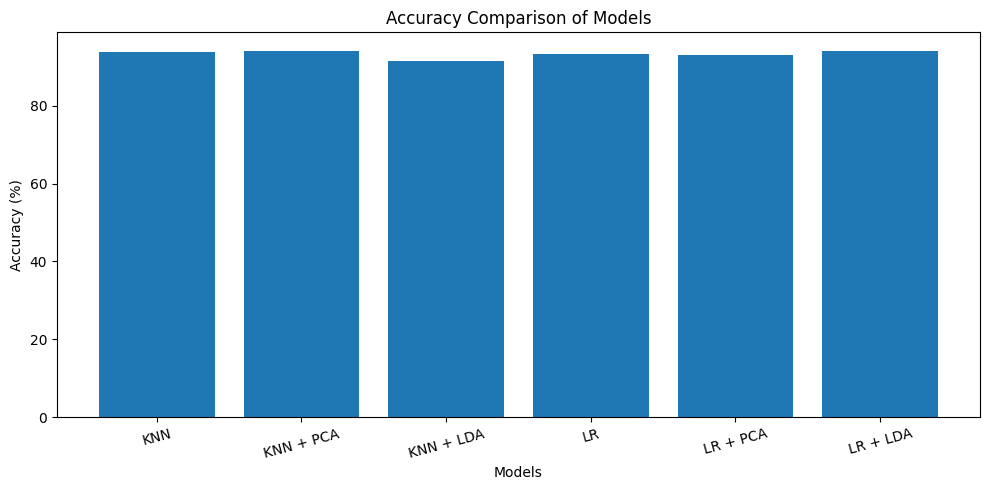

In [ ]:

# ACCURACY COMPARISON
import os
import matplotlib.pyplot as plt

# tạo folder images
os.makedirs("images", exist_ok=True)

# DỮ LIỆU

models = [
    'KNN',
    'KNN + PCA',
    'KNN + LDA',
    'LR',
    'LR + PCA',
    'LR + LDA'
]

accuracy = [
    93.8,
    94.2,
    91.5,
    93.4,
    93.0,
    94.2
]

# VẼ BIỂU ĐỒ

plt.figure(figsize=(10,5))

plt.bar(models, accuracy)

plt.ylabel("Accuracy (%)")
plt.xlabel("Models")

plt.title("Accuracy Comparison of Models")

plt.xticks(rotation=15)


plt.tight_layout()

plt.savefig(
    "images/accuracy_comparison.png",
    dpi=300
)

plt.show()

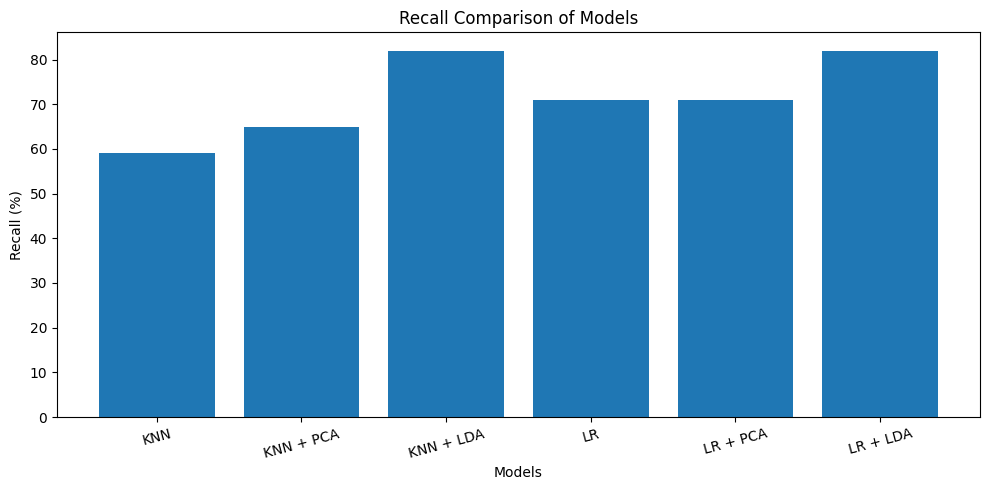

In [ ]:

# RECALL COMPARISON

import os
import matplotlib.pyplot as plt

# tạo folder images
os.makedirs("images", exist_ok=True)

models = [
    'KNN',
    'KNN + PCA',
    'KNN + LDA',
    'LR',
    'LR + PCA',
    'LR + LDA'
]

recall = [
    59,
    65,
    82,
    71,
    71,
    82
]

# VẼ BIỂU ĐỒ=

plt.figure(figsize=(10,5))

plt.bar(models, recall)

plt.ylabel("Recall (%)")
plt.xlabel("Models")

plt.title("Recall Comparison of Models")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "images/recall_comparison.png",
    dpi=300
)

plt.show()

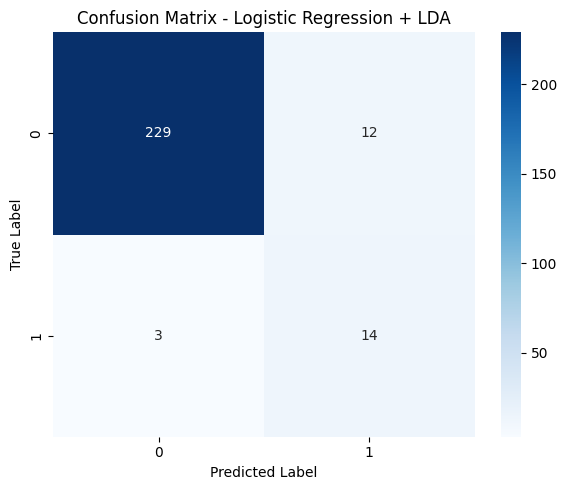

In [ ]:

# CONFUSION MATRIX

import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix

# tạo folder images
os.makedirs("images", exist_ok=True)

# CONFUSION MATRIX

# y_test: nhãn thật
# y_lr_lda: dự đoán từ Logistic + LDA

cm = confusion_matrix(
    y_test,
    y_lr_lda
)


# VẼ HEATMAP

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.title("Confusion Matrix - Logistic Regression + LDA")



plt.tight_layout()

plt.savefig(
    "images/confusion_matrix.png",
    dpi=300
)

plt.show()

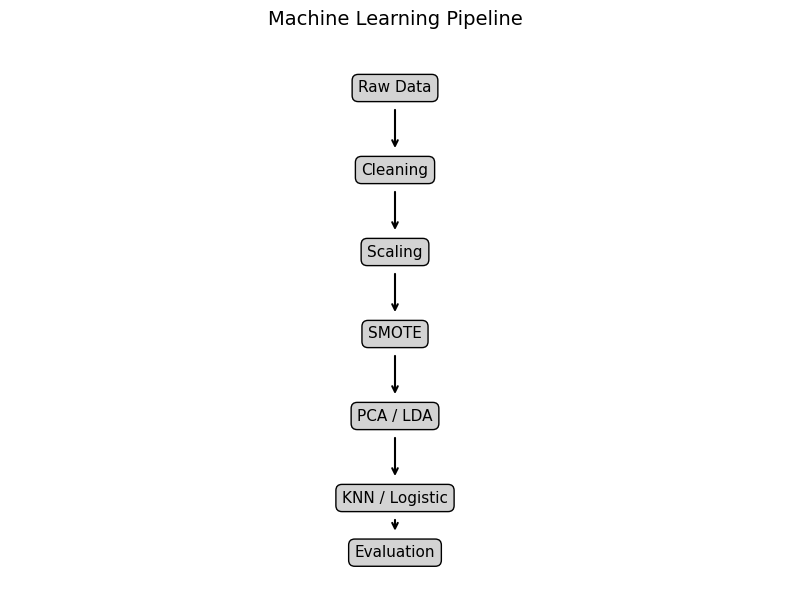

In [ ]:

# PIPELINE HỆ THỐNG

import os
import matplotlib.pyplot as plt

# tạo folder images
os.makedirs("images", exist_ok=True)


fig, ax = plt.subplots(figsize=(8,6))

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

ax.axis('off')

steps = [
    "Raw Data",
    "Cleaning",
    "Scaling",
    "SMOTE",
    "PCA / LDA",
    "KNN / Logistic",
    "Evaluation"
]

# tọa độ
x = 5

y_positions = [9, 7.5, 6, 4.5, 3, 1.5, 0.5]


# VẼ BOX
for step, y in zip(steps, y_positions):

    ax.text(
        x,
        y,
        step,
        ha='center',
        va='center',
        fontsize=11,
        bbox=dict(
            boxstyle="round,pad=0.4",
            edgecolor="black",
            facecolor="lightgray"
        )
    )

# VẼ MŨI TÊN

for i in range(len(y_positions)-1):

    ax.annotate(
        '',
        xy=(x, y_positions[i+1] + 0.35),
        xytext=(x, y_positions[i] - 0.35),
        arrowprops=dict(
            arrowstyle='->',
            lw=1.5
        )
    )


plt.title(
    "Machine Learning Pipeline",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    "images/pipeline.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

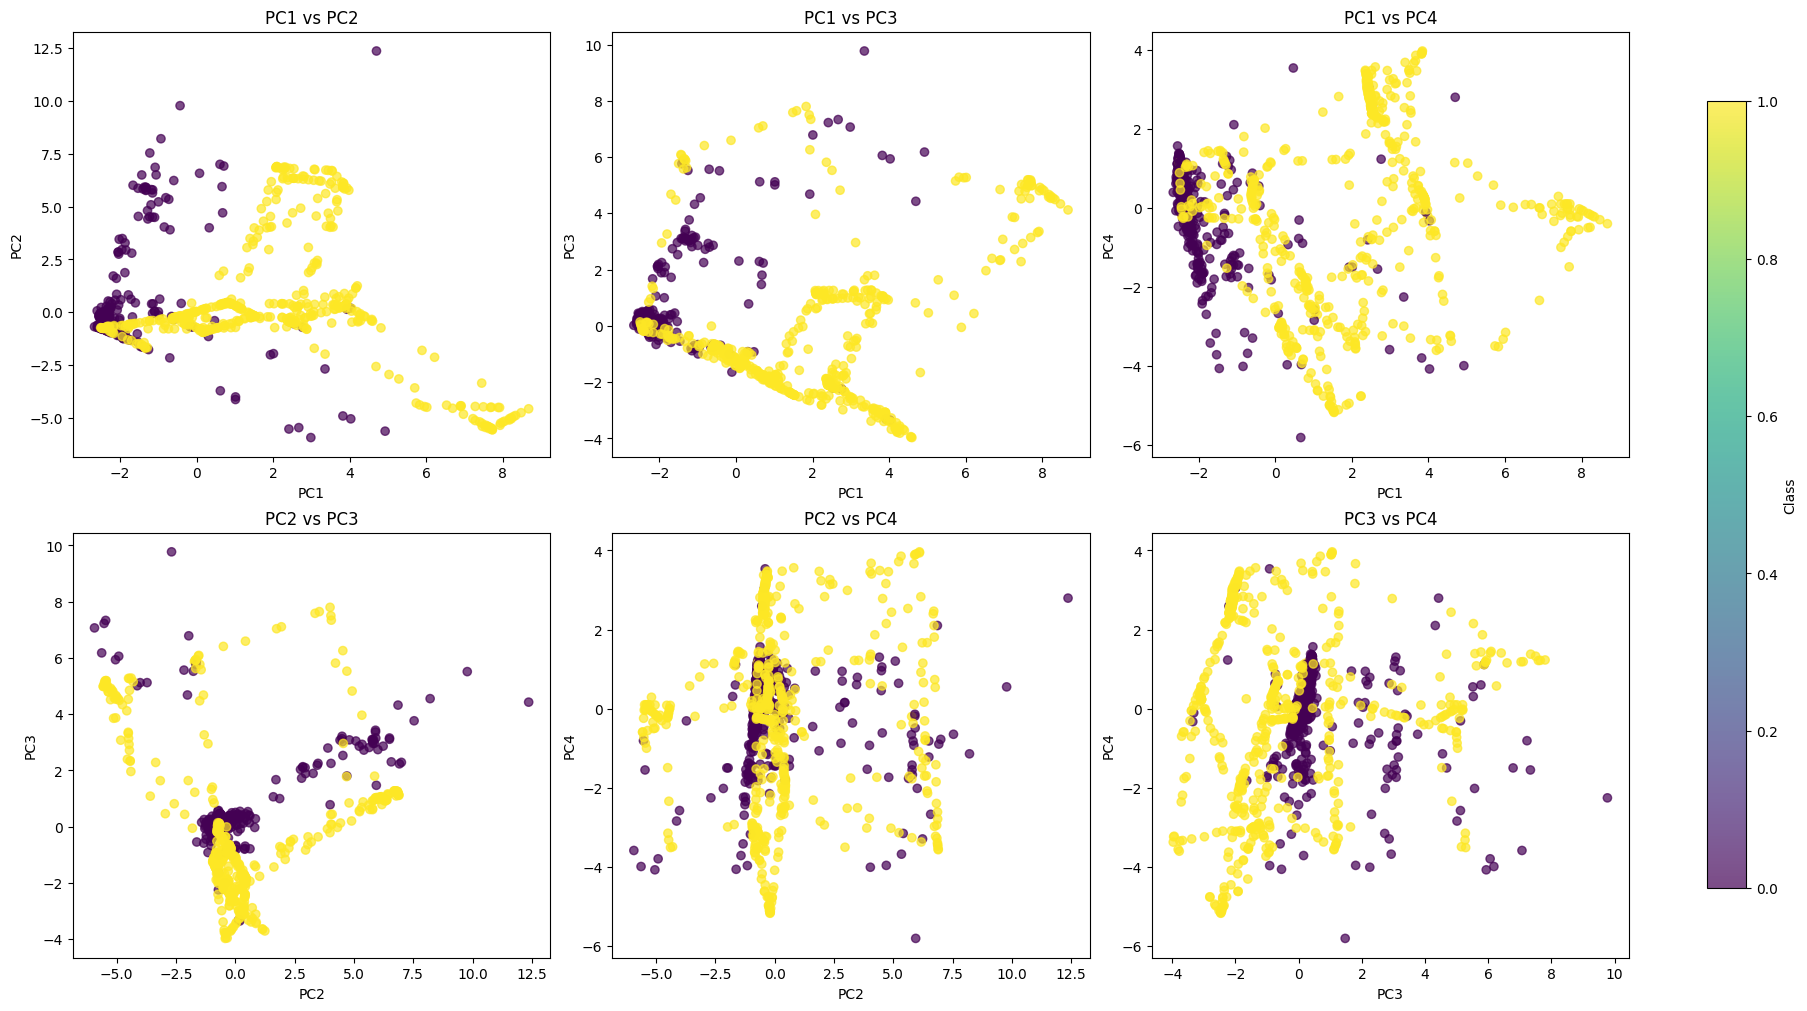

In [ ]:

# PCA 6 THÀNH PHẦN CHÍNH - HIỂN THỊ 6 HÌNH

import os
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

# tạo folder images
os.makedirs("images", exist_ok=True)

# GIẢM CHIỀU VỀ 6D

pca_6d = PCA(n_components=6)

X_pca_6d = pca_6d.fit_transform(
    X_train_scaled
)

# 6 CẶP PCA

pc_pairs = [
    (0, 1),   # PC1 vs PC2
    (0, 2),   # PC1 vs PC3
    (0, 3),   # PC1 vs PC4
    (1, 2),   # PC2 vs PC3
    (1, 3),   # PC2 vs PC4
    (2, 3)    # PC3 vs PC4
]

# TẠO LƯỚI 2x3
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 10),
    constrained_layout=True
)

axes = axes.flatten()

# VẼ

for i, (pc1, pc2) in enumerate(pc_pairs):

    scatter = axes[i].scatter(
        X_pca_6d[:, pc1],
        X_pca_6d[:, pc2],
        c=y_train,
        alpha=0.7
    )

    axes[i].set_xlabel(f"PC{pc1 + 1}")
    axes[i].set_ylabel(f"PC{pc2 + 1}")

    axes[i].set_title(
        f"PC{pc1 + 1} vs PC{pc2 + 1}"
    )

# COLORBAR

cbar = fig.colorbar(
    scatter,
    ax=axes,
    location="right",
    shrink=0.85
)

cbar.set_label("Class")


plt.savefig(
    "images/pca_6plots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()